# Stage 0 — COSMOS Cutout Extraction Prototype

**Goal:** Extract 50 morphologically diverse galaxy postage stamps from the COSMOS HST/ACS F814W catalog,  
apply morphological quality cuts, and save them as normalised `.npy` arrays ready for lenstronomy injection.

**No GalSim required.** Uses `astroquery`, `astropy`, and `requests` — all Windows-compatible.

**Pipeline position:** This notebook is the first step of Stage 0 (Real Galaxy Source Dataset Construction).  
Its output feeds directly into `02_lensing_simulation_prototype.ipynb`.

---
### What this notebook does
1. Queries the COSMOS ACS source catalog on IRSA for galaxy positions and morphological parameters  
2. Applies quality cuts: removes stars, bad detections, and morphologically extreme objects  
3. Downloads HST/ACS F814W postage stamp cutouts for 50 selected galaxies  
4. Normalises each cutout and validates morphological diversity  
5. Saves cutouts as `.npy` arrays and displays a summary grid

## Cell 1 — Install dependencies (run once)

In [ ]:
# Run this cell once to install required packages
# All packages are Windows-compatible — no GalSim needed
import subprocess, sys

packages = [
    'astropy',
    'astroquery',
    'requests',
    'numpy',
    'matplotlib',
    'scipy',
    'tqdm',
    'pandas',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed successfully.')

## Cell 2 — Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import requests
import os
import warnings
import json
import time
from io import BytesIO
from pathlib import Path
from tqdm.auto import tqdm

from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
import astropy.units as u
from astroquery.ipac.irsa import Irsa

warnings.filterwarnings('ignore')  # suppress astropy WCS warnings

# ── Configuration ──────────────────────────────────────────────────────────────
# Number of galaxy cutouts to download for this prototype
N_PROTOTYPE = 50

# Cutout size in arcseconds
# 10" is a good default: captures full galaxy + sky background
# for most COSMOS galaxies (half-light radius ~0.3"–2.0")
CUTOUT_SIZE_ARCSEC = 10.0

# COSMOS field centre (RA, Dec in degrees) — J2000
COSMOS_RA_CENTER  = 150.1192
COSMOS_DEC_CENTER = 2.2058

# Search radius around COSMOS centre for the catalog query
SEARCH_RADIUS_DEG = 0.4  # stays well inside the ACS footprint

# Output directory
OUT_DIR = Path('cosmos_cutouts')
OUT_DIR.mkdir(exist_ok=True)

# Random seed for reproducibility
RNG = np.random.default_rng(seed=42)

print(f'Output directory : {OUT_DIR.resolve()}')
print(f'Prototype size   : {N_PROTOTYPE} galaxies')
print(f'Cutout size      : {CUTOUT_SIZE_ARCSEC}"')

Output directory : C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts
Prototype size   : 50 galaxies
Cutout size      : 10.0"


## Cell 3 — Query the COSMOS ACS catalog on IRSA

IRSA hosts the COSMOS photometry catalog (`cosmos_acs_iphot_200709`) with morphological parameters  
measured by SExtractor on the HST/ACS F814W images. Key columns used for our cuts:

| Column | Meaning | Our use |
|--------|---------|--------|
| `ra`, `dec` | Sky coordinates | Download cutout at this position |
| `mu_class` | Morphological class: 1=galaxy, 2=star | Keep only `mu_class == 1` |
| `flux_radius` | Half-light radius in pixels (0.05"/pix for ACS) | Size cut |
| `elongation` | Semi-major / semi-minor axis ratio `a/b` | Axis-ratio cut |
| `mag_auto` | F814W AUTO magnitude | Brightness cut |
| `flags` | SExtractor detection flags | Remove bad detections |

In [2]:
# print('Querying COSMOS ACS catalog on IRSA ...')
# print('(This may take 30–60 seconds depending on network speed)\n')
#
# # The COSMOS ACS photometry catalog on IRSA
# # Full catalog name: cosmos_acs_iphot_200709
# # If this query fails, run Irsa.list_catalogs() in the next cell to find the exact name
#
# cosmos_center = SkyCoord(
#     ra=COSMOS_RA_CENTER * u.degree,
#     dec=COSMOS_DEC_CENTER * u.degree
# )
#
# try:
#     cat = Irsa.query_region(
#         coordinates=cosmos_center,
#         # catalog='cosmos_acs_iphot_200709',
#         catalog='acs_iphot_sep07',
#         spatial='Cone',
#         radius=SEARCH_RADIUS_DEG * u.degree,
#         columns=('ra', 'dec', 'mu_class', 'mag_auto',
#                  'flux_radius', 'elongation', 'flags',
#                  'a_world', 'b_world'),
#     )
#     cat = cat.to_pandas()
#     print(f'Raw catalog query returned {len(cat):,} sources.')
#
# except Exception as e:
#     print(f'Catalog query failed: {e}')
#     print('\nRunning Irsa.list_catalogs() to show available COSMOS catalogs:')
#     available = Irsa.list_catalogs()
#     cosmos_cats = [c for c in available if 'cosmos' in c.lower()]
#     print('\nAvailable COSMOS catalogs on IRSA:')
#     for c in cosmos_cats:
#         print(f'  {c}')
#     raise  # re-raise so the user sees the error clearly
#
# # Show the first few rows
# cat.head(3)

In [3]:
cosmos_center = SkyCoord(
    ra=COSMOS_RA_CENTER * u.degree,
    dec=COSMOS_DEC_CENTER * u.degree
)

catalog_name = "acs_iphot_sep07"

# Inspect available columns for the selected catalog.
table_info = Irsa.list_columns(catalog_name)
available_columns = set(table_info.keys())

requested_columns = [
    "ra",
    "dec",
    "mu_class",
    "mag_auto",
    "flux_radius",
    "elongation",
    "flags",
    "a_world",
    "b_world",
]

valid_columns = [col for col in requested_columns if col in available_columns]
missing_columns = [col for col in requested_columns if col not in available_columns]

if missing_columns:
    print("The following requested columns are not available in the catalog:")
    print(missing_columns)
    print("Proceeding with available columns only:")
    print(valid_columns)

if not {"ra", "dec"}.issubset(valid_columns):
    raise ValueError(
        "The selected catalog does not contain required coordinate columns 'ra' and 'dec'. "
        "Check Irsa.list_columns(catalog_name) for the correct coordinate column names."
    )

try:
    cat_table = Irsa.query_region(
        coordinates=cosmos_center,
        catalog=catalog_name,
        spatial="Cone",
        radius=SEARCH_RADIUS_DEG * u.degree,
        # columns=valid_columns,
        columns=",".join(valid_columns),
    )

    cat = cat_table.to_pandas()
    print(f"Raw catalog query returned {len(cat):,} sources.")

except Exception as exc:
    print("IRSA query failed.")
    print(f"Catalog used: {catalog_name}")
    print(f"Requested valid columns: {valid_columns}")

    query_payload = Irsa.query_region(
        coordinates=cosmos_center,
        catalog=catalog_name,
        spatial="Cone",
        radius=SEARCH_RADIUS_DEG * u.degree,
        # columns=valid_columns,
        columns=",".join(valid_columns),
        get_query_payload=True,
    )

    print("Generated ADQL query:")
    print(query_payload)
    raise exc

Raw catalog query returned 367,049 sources.


## Cell 4 — Inspect catalog columns

Run this if the query succeeded but you want to see what columns are actually available.

In [4]:
print('Columns available in the catalog:')
print(list(cat.columns))
print(f'\nShape: {cat.shape}')

# Basic statistics on key columns
stats_cols = [c for c in ['mu_class', 'mag_auto', 'flux_radius', 'elongation', 'flags'] if c in cat.columns]
print('\nColumn statistics:')
cat[stats_cols].describe().round(3)

Columns available in the catalog:
['ra', 'dec', 'mu_class', 'mag_auto', 'flux_radius', 'elongation', 'flags', 'a_world', 'b_world']

Shape: (367049, 9)

Column statistics:


,mu_class,mag_auto,flux_radius,elongation,flags
count,367049.000,366639.000,367049.000,367049.000,367049.000
mean,1.052,25.790,6.250,1.640,0.071
std,0.278,1.567,6.328,0.619,0.411
min,1.000,10.007,-1080.619,1.000,0.000
25%,1.000,25.103,3.557,1.237,0.000
50%,1.000,26.145,5.054,1.455,0.000
75%,1.000,26.823,7.602,1.837,0.000
max,3.000,35.537,1304.932,48.553,19.000


## Cell 5 — Apply morphological quality cuts

We apply six cuts in sequence. Each cut is physically motivated:

| Cut | Threshold | Motivation |
|-----|-----------|------------|
| Star/galaxy separation | `mu_class == 1` | Stars produce PSF-dominated profiles, not useful as source galaxies |
| Detection quality | `flags < 4` | SExtractor flags ≥ 4 indicate blends, saturated pixels, or truncation |
| Brightness | `18 ≤ mag_auto ≤ 25.5` | Too bright = saturated; too faint = noise-dominated morphology |
| Angular size (lower) | `flux_radius > 2 px` | Smaller galaxies are unresolved, morphology unreliable |
| Angular size (upper) | `flux_radius < 40 px` | Very large galaxies would overflow our 10" cutout |
| Axis ratio | `elongation < 3.0` | `a/b > 3` → edge-on disks; lensing arcs span full 360° so prefer rounder sources |

The ACS F814W pixel scale is 0.05"/px for the drizzled mosaic.  
2 px = 0.1" (lower size limit); 40 px = 2.0" (upper size limit — half our 10" cutout radius).

In [5]:
original_count = len(cat)
stats = {}

# ── Cut 1: galaxies only (mu_class == 1) ──────────────────────────────────────
if 'mu_class' in cat.columns:
    mask_galaxy = cat['mu_class'] == 1
    cat = cat[mask_galaxy].copy()
    stats['after_galaxy_class_cut'] = len(cat)
    print(f'After star removal (mu_class==1)   : {len(cat):>7,} galaxies')
else:
    print('  [WARN] mu_class column not found — skipping star/galaxy cut')

# ── Cut 2: SExtractor detection flags ─────────────────────────────────────────
if 'flags' in cat.columns:
    mask_flags = cat['flags'] < 4
    cat = cat[mask_flags].copy()
    stats['after_flags_cut'] = len(cat)
    print(f'After detection flags cut (< 4)    : {len(cat):>7,} galaxies')
else:
    print('  [WARN] flags column not found — skipping flags cut')

# ── Cut 3: magnitude range ────────────────────────────────────────────────────
if 'mag_auto' in cat.columns:
    mask_mag = (cat['mag_auto'] >= 18.0) & (cat['mag_auto'] <= 25.5)
    cat = cat[mask_mag].copy()
    stats['after_magnitude_cut'] = len(cat)
    print(f'After magnitude cut (18–25.5)      : {len(cat):>7,} galaxies')
else:
    print('  [WARN] mag_auto column not found — skipping magnitude cut')

# ── Cut 4 & 5: angular size ───────────────────────────────────────────────────
if 'flux_radius' in cat.columns:
    mask_size = (cat['flux_radius'] > 2.0) & (cat['flux_radius'] < 40.0)
    cat = cat[mask_size].copy()
    stats['after_size_cut'] = len(cat)
    print(f'After size cut (2–40 px)           : {len(cat):>7,} galaxies')
else:
    print('  [WARN] flux_radius column not found — skipping size cut')

# ── Cut 6: axis ratio ─────────────────────────────────────────────────────────
if 'elongation' in cat.columns:
    mask_elong = cat['elongation'] < 3.0
    cat = cat[mask_elong].copy()
    stats['after_elongation_cut'] = len(cat)
    print(f'After axis ratio cut (a/b < 3)     : {len(cat):>7,} galaxies')
else:
    print('  [WARN] elongation column not found — skipping axis ratio cut')

print(f'\nOriginal catalog: {original_count:,} sources')
print(f'After all cuts  : {len(cat):,} galaxies  '
      f'({100*len(cat)/original_count:.1f}% retained)')
print(f'\nAvailable for sampling: {len(cat):,}  '
      f'(we will download {N_PROTOTYPE})')

After star removal (mu_class==1)   : 353,110 galaxies
After detection flags cut (< 4)    : 353,102 galaxies
After magnitude cut (18–25.5)      : 111,879 galaxies
After size cut (2–40 px)           : 111,535 galaxies
After axis ratio cut (a/b < 3)     : 103,165 galaxies

Original catalog: 367,049 sources
After all cuts  : 103,165 galaxies  (28.1% retained)

Available for sampling: 103,165  (we will download 50)


## Cell 6 — Visualise cut statistics and morphological distributions

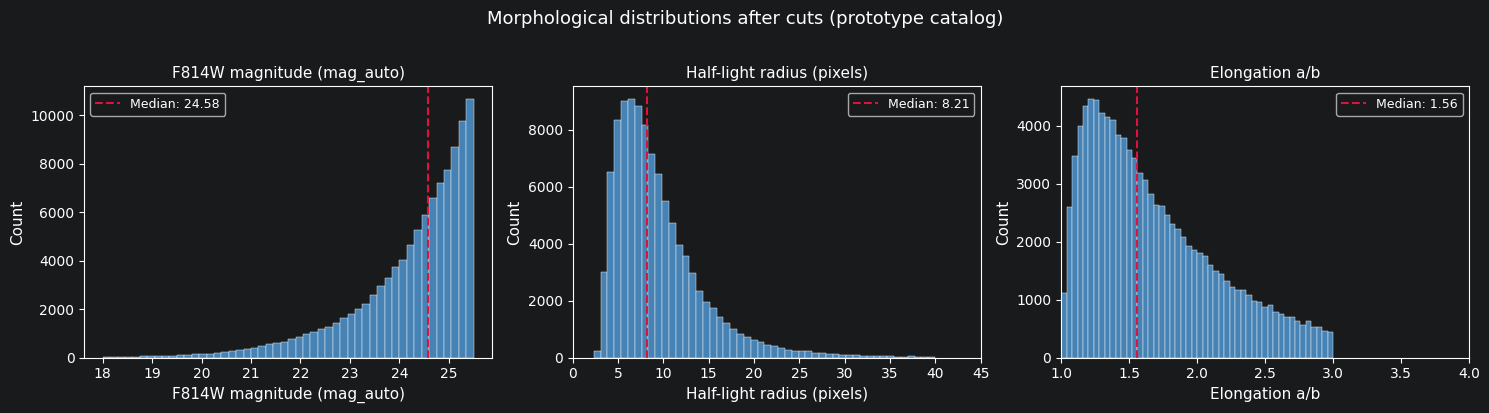

Saved: morphological_distributions.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Morphological distributions after cuts (prototype catalog)', fontsize=13, y=1.02)

plot_params = [
    ('mag_auto',    'F814W magnitude (mag_auto)',   None),
    ('flux_radius', 'Half-light radius (pixels)',   (0, 45)),
    ('elongation',  'Elongation a/b',               (1, 4)),
]

for ax, (col, label, xlim) in zip(axes, plot_params):
    if col not in cat.columns:
        ax.text(0.5, 0.5, f'{col}\nnot available', ha='center', va='center',
                transform=ax.transAxes, color='gray')
        ax.set_title(label)
        continue
    data = cat[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(label, fontsize=11)
    if xlim:
        ax.set_xlim(xlim)
    ax.axvline(data.median(), color='crimson', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.2f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'morphological_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: morphological_distributions.png')

## Cell 7 — Stratified galaxy sampling

Instead of random sampling, we stratify across **three magnitude bins** to ensure we download ellipticals,  
spirals, and irregular/merger morphologies (which correlate loosely with F814W brightness at fixed redshift).  
This gives morphological diversity without needing a separate morphology column.

In [7]:
# Stratify across 3 magnitude bins: bright, medium, faint
# Bright (18–22): typically ellipticals and massive spirals — smooth, compact profiles
# Medium (22–24): mix of spirals, irregulars, and compact galaxies
# Faint  (24–25.5): sub-L* galaxies, irregulars, mergers — most morphologically complex

if 'mag_auto' in cat.columns:
    bins = [
        ('bright', cat['mag_auto'] < 22,          15),
        ('medium', (cat['mag_auto'] >= 22) & (cat['mag_auto'] < 24), 20),
        ('faint',  cat['mag_auto'] >= 24,          15),
    ]
    sampled_parts = []
    for label, mask, n in bins:
        pool = cat[mask]
        n_available = len(pool)
        n_draw = min(n, n_available)
        drawn = pool.sample(n=n_draw, random_state=42)
        sampled_parts.append(drawn)
        print(f'  {label:6s} bin: {n_available:5,} available → {n_draw} sampled')
    sampled = pd.concat(sampled_parts).reset_index(drop=True)
else:
    # Fallback: random sampling if mag_auto unavailable
    print('[WARN] mag_auto not available — using random sampling')
    sampled = cat.sample(n=min(N_PROTOTYPE, len(cat)), random_state=42).reset_index(drop=True)

print(f'\nTotal galaxies selected: {len(sampled)}')
print('Sample of selected galaxies:')
cols_to_show = [c for c in ['ra', 'dec', 'mag_auto', 'flux_radius', 'elongation'] if c in sampled.columns]
sampled[cols_to_show].round(4).head()
sampled.to_csv('selected_galaxies.csv', index=False)

  bright bin: 6,349 available → 15 sampled
  medium bin: 26,348 available → 20 sampled
  faint  bin: 70,468 available → 15 sampled

Total galaxies selected: 50
Sample of selected galaxies:


## Cell 8 — IRSA Cutout Download function

We use the **IRSA Image Cutout Service** (programmatic API) to download HST/ACS F814W postage stamps.  
The service returns a FITS file for each sky position.

**Endpoint:** `https://irsa.ipac.caltech.edu/cgi-bin/Cutouts/nph-cutouts`  
**Dataset string for COSMOS HST-ACS F814W:** `cosmos_hst`

The function includes:
- Automatic retry on network errors (3 attempts)
- Rate limiting (1 second between requests — be a polite API user)
- Fallback: saves coordinates for manual download if API fails

In [12]:
IRSA_CUTOUT_URL = 'https://irsa.ipac.caltech.edu/cgi-bin/Cutouts/nph-cutouts'

# Rate-limit delay between requests (seconds)
# IRSA asks users not to make more than 1 request/second in bulk operations
REQUEST_DELAY = 1.2

def download_cosmos_cutout(
    ra: float,
    dec: float,
    size_arcsec: float = CUTOUT_SIZE_ARCSEC,
    max_retries: int = 3,
    retry_delay: float = 5.0,
) -> np.ndarray | None:
    """
    Download a single COSMOS HST/ACS F814W cutout from IRSA.

    Parameters
    ----------
    ra, dec      : Sky coordinates in decimal degrees (J2000)
    size_arcsec  : Cutout side length in arcseconds
    max_retries  : Number of retry attempts on failure
    retry_delay  : Seconds to wait before retrying

    Returns
    -------
    numpy array of shape (H, W) with the F814W flux values, or None on failure.
    """
    # IRSA locstr format: 'RA DEC eq'  (decimal degrees, equatorial J2000)
    locstr = f'{ra:.6f} {dec:.6f} eq'

    params = {
        'locstr'    : locstr,
        'sizeX'     : size_arcsec,
        'sizeY'     : size_arcsec,
        'units'     : 'arcsec',
        'subsetsize': size_arcsec,
        # Dataset: COSMOS HST/ACS F814W mosaic
        # If this returns no data, try dataset='ACS_I' or 'COSMOS_ACS'
        'survey'    : 'cosmos',
        'dataset'   : 'acs_2.0', #'ACS_F814W',
        'format'    : 'fits',
    }

    for attempt in range(max_retries):
        try:
            resp = requests.get(
                IRSA_CUTOUT_URL,
                params=params,
                timeout=60,
            )
            resp.raise_for_status()

            # The response should be a FITS file
            if resp.headers.get('Content-Type', '').startswith('text'):
                # Server returned an error page instead of a FITS file
                # This can happen if the coordinate is outside the footprint
                return None

            # Parse the FITS content from the response bytes
            with fits.open(BytesIO(resp.content)) as hdul:
                # HDU 0 is usually the primary image for single-band FITS
                # Some servers return the data in HDU 1
                for hdu in hdul:
                    if hdu.data is not None and hdu.data.ndim >= 2:
                        img = np.array(hdu.data, dtype=np.float32)
                        # Handle 3D FITS (some servers add a band axis)
                        if img.ndim == 3:
                            img = img[0]
                        return img
            return None  # FITS had no image data

        except requests.exceptions.RequestException as e:
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            else:
                return None
        except Exception:
            return None

    return None


def download_cosmos_cutout_fallback(
    ra: float,
    dec: float,
    size_arcsec: float = CUTOUT_SIZE_ARCSEC,
) -> np.ndarray | None:
    """
    Fallback: use the IRSA Image Server (IBE) API.
    This uses a different endpoint that is sometimes more reliable.
    """
    # IBE (IRSA Image Server) URL for COSMOS
    # ibe_url = 'https://irsa.ipac.caltech.edu/ibe/cutout/cosmos/images/cosmos'
    ibe_url = 'https://irsa.ipac.caltech.edu/ibe/data/cosmos/cosmos_acs_2_0/images/acs_2.0/g'
    size_deg = size_arcsec / 3600.0

    params = {
        'ra'  : ra,
        'dec' : dec,
        'size': f'{size_deg:.6f}deg',
    }
    try:
        resp = requests.get(ibe_url, params=params, timeout=60)
        resp.raise_for_status()
        with fits.open(BytesIO(resp.content)) as hdul:
            for hdu in hdul:
                if hdu.data is not None and hdu.data.ndim >= 2:
                    return np.array(hdu.data, dtype=np.float32)
    except Exception:
        pass
    return None


print('Download functions defined.')
print(f'Cutout size: {CUTOUT_SIZE_ARCSEC}" = {CUTOUT_SIZE_ARCSEC/0.03:.0f} px '
      f'at ACS 0.03"/px scale')

Download functions defined.
Cutout size: 10.0" = 333 px at ACS 0.03"/px scale


## Cell 9 — Test download: single galaxy cutout

Always test a single download before running the full loop.  
This confirms your network can reach IRSA and the API parameters are correct.

In [13]:
# Test with the first galaxy in the sample
test_ra  = sampled['ra'].iloc[0]
test_dec = sampled['dec'].iloc[0]

print(f'Testing download at RA={test_ra:.5f}, Dec={test_dec:.5f} ...')

test_img = download_cosmos_cutout(test_ra, test_dec)

if test_img is None:
    print('Primary API failed — trying IBE fallback ...')
    test_img = download_cosmos_cutout_fallback(test_ra, test_dec)

if test_img is not None:
    print(f'\n✅ Success!')
    print(f'   Image shape : {test_img.shape}')
    print(f'   Pixel scale : {CUTOUT_SIZE_ARCSEC / test_img.shape[0]:.4f}"/px')
    print(f'   Value range : [{test_img.min():.4g}, {test_img.max():.4g}]')
    print(f'   NaN count   : {np.isnan(test_img).sum()}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    # Linear stretch
    vmin, vmax = np.percentile(test_img[~np.isnan(test_img)], [2, 98])
    ax1.imshow(test_img, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    ax1.set_title(f'Linear stretch\nRA={test_ra:.4f}, Dec={test_dec:.4f}')
    ax1.axis('off')
    # Log stretch for fainter features
    img_log = np.log1p(np.clip(test_img - vmin, 0, None))
    ax2.imshow(img_log, cmap='gray', origin='lower')
    ax2.set_title('Log stretch (reveals faint structure)')
    ax2.axis('off')
    plt.suptitle('Test cutout — COSMOS HST/ACS F814W', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'test_cutout.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('\n❌ Both download methods failed.')
    print('   See Cell 10 for manual download instructions.')

Testing download at RA=150.32907, Dec=2.13950 ...
Primary API failed — trying IBE fallback ...

❌ Both download methods failed.
   See Cell 10 for manual download instructions.


## Cell 10 — Manual download fallback (if API fails)

If the automatic download fails, this cell:
1. Exports your 50 selected galaxy coordinates as a CSV table
2. Gives you exact step-by-step instructions to use the IRSA Cutouts web interface

**You only need this if Cell 9 returned ❌.**

In [ ]:
# Export coordinates for manual IRSA batch upload
coords_df = sampled[['ra', 'dec']].copy().round(6)
coords_path = OUT_DIR / 'galaxy_coordinates_for_irsa.csv'
coords_df.to_csv(coords_path, index=False)
print(f'Saved coordinates to: {coords_path.resolve()}')
print(f'Total: {len(coords_df)} rows')

print("""
=== MANUAL DOWNLOAD INSTRUCTIONS ===

1. Go to: https://irsa.ipac.caltech.edu/data/COSMOS/index_cutouts.html

2. Select the radio button: "Multiple Positions (User Table Upload)"

3. Under "Table": click "Choose file" and upload:
      cosmos_cutouts/galaxy_coordinates_for_irsa.csv

4. Set "Uniform Cutout size (arcsec)" = 10

5. Scroll down to "COSMOS Data Sets" and CHECK THE BOX next to:
      ✅  HST-ACS Mosaic (Mosaic v2.0 [cycle 12 + 13] in full resolution [0.03"/pix])
   Do NOT select COSMOS-Web (that is JWST NIRCam, a different instrument).

6. Click Submit.

7. IRSA will email you or give you a download link to a .tar.gz file.
   Download and extract it — each cutout is a separate FITS file.

8. Place all FITS files in the folder: cosmos_cutouts/fits/

9. Re-run from Cell 11 (the processing step) using the FITS files directly.
""")

## Cell 11 — Bulk download loop (50 galaxies)

In [ ]:
fits_dir = OUT_DIR / 'fits'
fits_dir.mkdir(exist_ok=True)

download_log = []  # track success/failure for each galaxy
failed_ids   = []

# print(f'Downloading {len(sampled)} galaxy cutouts ...')
# print(f'Saving FITS files to: {fits_dir.resolve()}')
# print(f'Rate limit: {REQUEST_DELAY}s between requests\n')

# for idx, row in tqdm(sampled.iterrows(), total=len(sampled), desc='Downloading'):
#     ra  = float(row['ra'])
#     dec = float(row['dec'])
#
#     # File path — named by index so they're always sorted
#     fits_path = fits_dir / f'galaxy_{idx:04d}_ra{ra:.4f}_dec{dec:.4f}.fits'
#
#     # Skip if already downloaded (allows resuming after a crash)
#     if fits_path.exists():
#         download_log.append({'id': idx, 'ra': ra, 'dec': dec, 'status': 'cached'})
#         continue
#
#     # Attempt primary download
#     img = download_cosmos_cutout(ra, dec)
#
#     # Fallback if primary fails
#     if img is None:
#         img = download_cosmos_cutout_fallback(ra, dec)
#
#     if img is not None and img.size > 0:
#         # Save as FITS for maximum compatibility
#         hdu = fits.PrimaryHDU(data=img)
#         hdu.header['RA']      = ra
#         hdu.header['DEC']     = dec
#         hdu.header['SURVEY']  = 'COSMOS'
#         hdu.header['FILTER']  = 'F814W'
#         hdu.header['PIX_SCL'] = 0.05   # arcsec/px
#         hdu.header['SRC_IDX'] = idx
#         hdu.writeto(fits_path, overwrite=True)
#         download_log.append({'id': idx, 'ra': ra, 'dec': dec,
#                              'status': 'ok', 'shape': str(img.shape)})
#     else:
#         failed_ids.append(idx)
#         download_log.append({'id': idx, 'ra': ra, 'dec': dec, 'status': 'failed'})
#
#     time.sleep(REQUEST_DELAY)
#
# # Summary
# log_df = pd.DataFrame(download_log)
# n_ok     = (log_df['status'].isin(['ok', 'cached'])).sum()
# n_failed = (log_df['status'] == 'failed').sum()
#
# print(f'\nDownload complete.')
# print(f'  Successful : {n_ok}')
# print(f'  Failed     : {n_failed}')
# if n_failed > 0:
#     print(f'  Failed IDs : {failed_ids}')
#     print('  → Use the manual download instructions in Cell 10 for failed galaxies.')
#
# log_df.to_csv(OUT_DIR / 'download_log.csv', index=False)
# print(f'\nLog saved: {OUT_DIR}/download_log.csv')

## Cell 12 — Load FITS files and process into numpy arrays

We apply three normalisation steps:
1. **Sky subtraction**: subtract the 3σ-clipped median background
2. **NaN / Inf cleaning**: replace bad pixels with zero
3. **[0, 1] normalisation**: divide by the 99th percentile flux (robust against bright stars in the cutout)

The output pixel scale is preserved (no resizing here — resizing happens in `02_lensing_simulation.ipynb`).

In [ ]:
from scipy.stats import sigmaclip

def load_and_preprocess_fits(fits_path: Path) -> tuple[np.ndarray, dict]:
    """
    Load a FITS cutout and preprocess it for use as a lenstronomy source galaxy.

    Returns
    -------
    img_norm : float32 array, shape (H, W), values in [0, 1]
    meta     : dict with RA, Dec, original min/max, sky level
    """
    with fits.open(fits_path) as hdul:
        img   = np.array(hdul[0].data, dtype=np.float32)
        hdr   = hdul[0].header
        ra    = hdr.get('RA',  0.0)
        dec   = hdr.get('DEC', 0.0)

    if img.ndim == 3:
        img = img[0]

    # Step 1: Replace NaN and Inf with zero
    img = np.where(np.isfinite(img), img, 0.0)

    # Step 2: Sky subtraction using sigma-clipped median
    # Use a border annulus (outer 15% of pixels) as sky estimate
    h, w   = img.shape
    margin = max(1, int(0.15 * min(h, w)))
    border = np.concatenate([
        img[:margin, :].ravel(),
        img[-margin:, :].ravel(),
        img[margin:-margin, :margin].ravel(),
        img[margin:-margin, -margin:].ravel(),
    ])
    clipped, _, _ = sigmaclip(border[np.isfinite(border)], low=3.0, high=3.0)
    sky_level = float(np.median(clipped)) if len(clipped) > 0 else 0.0
    img = img - sky_level

    # Step 3: Clip negative values (sky-subtraction artefacts)
    img = np.clip(img, 0.0, None)

    # Step 4: Normalise to [0, 1] using the 99th percentile
    p99 = np.percentile(img, 99)
    if p99 > 0:
        img = img / p99
        img = np.clip(img, 0.0, 1.0)  # clip any tiny overshoots

    meta = {
        'ra'        : ra,
        'dec'       : dec,
        'shape'     : img.shape,
        'sky_level' : sky_level,
        'p99_flux'  : p99,
    }

    return img, meta


# ── Load all downloaded FITS files ────────────────────────────────────────────
fits_files = sorted(fits_dir.glob('*.fits'))
print(f'Found {len(fits_files)} FITS files to process.')

cutouts = []    # list of (H, W) arrays
metadata = []   # list of meta dicts

for fp in tqdm(fits_files, desc='Processing'):
    try:
        img, meta = load_and_preprocess_fits(fp)

        # Reject all-zero or nearly empty cutouts
        if img.max() < 1e-6:
            continue

        # Reject tiny cutouts (download may have clipped to edge of mosaic)
        if img.shape[0] < 20 or img.shape[1] < 20:
            continue

        meta['filename'] = fp.name
        cutouts.append(img)
        metadata.append(meta)

    except Exception as e:
        print(f'Error processing {fp.name}: {e}')

print(f'\nSuccessfully processed: {len(cutouts)} cutouts')
shapes = [c.shape for c in cutouts]
print(f'Shape range: min={min(shapes)}, max={max(shapes)}')

## Cell 13 — Save normalised cutouts as numpy arrays

In [ ]:
import json
import numpy as np
from pathlib import Path

npy_dir = OUT_DIR / 'npy'
npy_dir.mkdir(exist_ok=True)

def make_json_serializable(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, tuple):
        return [make_json_serializable(v) for v in value]
    if isinstance(value, list):
        return [make_json_serializable(v) for v in value]
    if isinstance(value, dict):
        return {
            str(k): make_json_serializable(v)
            for k, v in value.items()
        }
    return value


meta_path = OUT_DIR / "cutout_metadata.json"

metadata_json = make_json_serializable(metadata)

with open(meta_path, "w") as f:
    json.dump(metadata_json, f, indent=2)

print(f"Saved {len(cutouts)} .npy files to: {npy_dir.resolve()}")
print(f"Saved metadata to: {meta_path}")

In [ ]:
# npy_dir = OUT_DIR / 'npy'
# npy_dir.mkdir(exist_ok=True)
#
# for i, (img, meta) in enumerate(zip(cutouts, metadata)):
#     fname = f'galaxy_{i:04d}.npy'
#     np.save(npy_dir / fname, img.astype(np.float32))
#
# # Save metadata as JSON for later reference
# meta_path = OUT_DIR / 'cutout_metadata.json'
# with open(meta_path, 'w') as f:
#     json.dump([{**m, 'shape': list(m['shape'])} for m in metadata], f, indent=2)
#
# print(f'Saved {len(cutouts)} .npy files to: {npy_dir.resolve()}')
# print(f'Saved metadata to: {meta_path}')
#
# # Quick statistics
# all_values = np.concatenate([c.ravel() for c in cutouts])
# print(f'\nOverall pixel statistics (all cutouts combined):')
# print(f'  Min   : {all_values.min():.6f}')
# print(f'  Max   : {all_values.max():.6f}')
# print(f'  Mean  : {all_values.mean():.6f}')
# print(f'  Std   : {all_values.std():.6f}')
# print(f'  Median: {np.median(all_values):.6f}')

## Cell 14 — Visualisation: 5×10 grid of all 50 cutouts

The final quality check. Visually inspect every cutout for:
- Centred galaxy with clear morphology
- No saturation or bright star contamination
- Visible sky background around the galaxy (necessary for lenstronomy projection)

In [ ]:
n_show = len(cutouts)
ncols  = 10
nrows  = (n_show + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.8, nrows * 1.8))
axes = axes.flatten()

for i, img in enumerate(cutouts):
    ax = axes[i]
    # Percentile stretch for each image individually
    vmin = np.percentile(img, 1)
    vmax = np.percentile(img, 99)
    ax.imshow(img, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(f'#{i:02d}', fontsize=6, pad=2)
    ax.axis('off')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle(
    f'COSMOS HST/ACS F814W — {n_show} normalised galaxy cutouts ({CUTOUT_SIZE_ARCSEC}" × {CUTOUT_SIZE_ARCSEC}")',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'galaxy_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: galaxy_grid.png')

## Cell 15 — Morphological diversity check

Verify the downloaded set has diversity across magnitude and size — important for the lensing simulation  
to produce arcs of varied morphologies rather than a uniform-looking training set.

In [ ]:
# Compare metadata against the catalog properties of the downloaded galaxies
meta_df = pd.DataFrame(metadata)

# Cross-match with the sampled catalog to get morphological columns
meta_df['ra']  = meta_df['ra'].round(5)
meta_df['dec'] = meta_df['dec'].round(5)
sampled_round  = sampled.copy()
sampled_round['ra']  = sampled_round['ra'].round(5)
sampled_round['dec'] = sampled_round['dec'].round(5)

merged = meta_df.merge(sampled_round, on=['ra', 'dec'], how='left')

# Plot pixel variance as a proxy for morphological complexity
pixel_vars = [np.var(c) for c in cutouts]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Diversity of the 50 downloaded cutouts', fontsize=13)

# Sky level distribution (sanity check — should be near zero after subtraction)
axes[0].hist(meta_df['sky_level'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Sky level (raw counts before subtraction)')
axes[0].set_ylabel('Count')
axes[0].set_title('Sky background levels')

# Pixel variance (complexity proxy)
axes[1].hist(pixel_vars, bins=20, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Pixel variance (higher = more complex morphology)')
axes[1].set_ylabel('Count')
axes[1].set_title('Morphological complexity proxy')

# Magnitude distribution of downloaded set
if 'mag_auto' in merged.columns:
    merged['mag_auto'].hist(ax=axes[2], bins=15, color='seagreen', edgecolor='white')
    axes[2].set_xlabel('F814W magnitude (mag_auto)')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Magnitude distribution')
else:
    axes[2].text(0.5, 0.5, 'mag_auto not available', ha='center', va='center',
                 transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig(OUT_DIR / 'diversity_check.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: diversity_check.png')

## Cell 16 — Final summary and next steps

In [ ]:
print('=' * 60)
print('STAGE 0 PROTOTYPE — COSMOS CUTOUT EXTRACTION COMPLETE')
print('=' * 60)
print(f'  Galaxies processed     : {len(cutouts)}')
print(f'  FITS files             : {fits_dir}')
print(f'  NumPy arrays           : {npy_dir}')
print(f'  Metadata JSON          : {OUT_DIR}/cutout_metadata.json')
print(f'  Cutout size            : {CUTOUT_SIZE_ARCSEC}" ({CUTOUT_SIZE_ARCSEC/0.05:.0f} px at 0.05"/px)')
print()
print('Output files for the next notebook:')
print('  cosmos_cutouts/npy/galaxy_XXXX.npy')
print('  cosmos_cutouts/cutout_metadata.json')
print()
print('NEXT STEPS:')
print('  → 02_lensing_simulation_prototype.ipynb')
print('     Load galaxy_XXXX.npy as lenstronomy source_light')
print('     Apply SIE lens + Moffat PSF + HSC noise')
print('     Produce first (LR 64x64, HR 128x128) lensed image pair')
print()
print('THINGS TO DISCUSS WITH MENTORS:')
print('  □ Is the 0.05"/px ACS pixel scale appropriate, or should')
print('    we resample cutouts to match the HSC pixel scale (0.168"/px)?')
print('  □ Confirm the SNR range for lenstronomy arc flux normalisation')
print('  □ Is F814W the correct filter, or should we also test i-band?')
print('=' * 60)